# OCT Q1 - Resume Notebook (Add-ons 2-4 only, single GPU)

This is a slimmed re-run notebook. The base 5-fold ResNet-50 training and **Add-on 1 (matched XAI)** are already complete, so they are **not** recomputed here - their checkpoints/outputs are imported from the previous run. Only **Add-on 2 (ConvNeXt)**, **Add-on 3 (leakage severity)** and **Add-on 4 (natural imbalance)** actually train, and everything runs on a **single GPU** for stability.

**One-time setup:** in the right sidebar click **Add Input** and attach the previous notebook's **Output** (the version that produced `q1_oct/checkpoints/`) *or* its results `.zip`. Then Run All.

In [1]:
import warnings, os, time
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # [SINGLE-GPU] use one GPU only to avoid the multi-GPU memory crash
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path
import torchvision.transforms as T
import torchvision.models as models
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from statsmodels.stats.contingency_tables import mcnemar
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
# --- [ADDED] Fast GPU sanity check -------------------------------------------
# Fails in ~1s with a clear message if the assigned GPU cannot run CUDA kernels,
# instead of crashing several minutes later during training. No modeling logic
# is changed; this only probes the device with a tiny conv+batchnorm+backward.
if DEVICE.type == 'cuda':
    try:
        _probe = nn.Sequential(nn.Conv2d(3, 8, 3), nn.BatchNorm2d(8)).to(DEVICE)
        _probe(torch.randn(2, 3, 32, 32, device=DEVICE)).sum().backward()
        torch.cuda.synchronize()
        _cap = torch.cuda.get_device_capability(0)
        print(f'GPU sanity check passed: {torch.cuda.get_device_name(0)} (sm_{_cap[0]}{_cap[1]}) | torch {torch.__version__}')
        del _probe; torch.cuda.empty_cache()
    except RuntimeError as _e:
        raise RuntimeError(
            "GPU cannot execute CUDA kernels: 'no kernel image is available for execution "
            "on the device' (cudaErrorNoKernelImageForDevice).\n"
            "This is a Kaggle accelerator/hardware<->torch mismatch, NOT a bug in this notebook.\n"
            "HOW TO FIX (right sidebar > Session options > Accelerator):\n"
            "  1) Switch accelerator to 'GPU P100' (single GPU) instead of 'GPU T4 x2' (or vice-versa).\n"
            "  2) Set Environment to 'Always use latest'.\n"
            "  3) Factory reset / restart the session, then Run All again.\n"
            f"GPU seen: {torch.cuda.get_device_name(0)} | torch {torch.__version__}\n"
            f"Original error: {_e}"
        ) from _e
else:
    print('WARNING: CUDA not available - training on CPU will be extremely slow.')

GPU sanity check passed: Tesla T4 (sm_75) | torch 2.10.0+cu128


In [3]:
IMG_SIZE=224; BATCH=32; EPOCHS=12; LR=1e-4; FOLDS=5; PATIENCE=3
SEED=42
OUT=Path('/kaggle/working/q1_oct'); OUT.mkdir(exist_ok=True)

In [4]:
# ====== [ADDED] CHECKPOINT / RESUME LAYER (safe re-run, no logic change) ======
# Saves each trained model + fold results to /kaggle/working so that if the
# kernel crashes, re-running re-loads finished steps instead of retraining.
import pickle
CKPT = OUT/'checkpoints'; CKPT.mkdir(parents=True, exist_ok=True)

def _sd(m):
    return (m.module if isinstance(m, nn.DataParallel) else m).state_dict()

def save_model_ckpt(m, tag):
    torch.save(_sd(m), CKPT/f'{tag}.pt')

def load_model_ckpt(model_fn, tag):
    p = CKPT/f'{tag}.pt'
    if not p.exists():
        return None
    m = model_fn()
    (m.module if isinstance(m, nn.DataParallel) else m).load_state_dict(torch.load(p, map_location=DEVICE))
    m.eval()
    return m

def save_pkl_ckpt(obj, tag):
    with open(CKPT/f'{tag}.pkl', 'wb') as fh:
        pickle.dump(obj, fh)

def load_pkl_ckpt(tag):
    p = CKPT/f'{tag}.pkl'
    if not p.exists():
        return None
    with open(p, 'rb') as fh:
        return pickle.load(fh)

def has_ckpt(tag):
    return (CKPT/f'{tag}.pkl').exists()

def strip_model(d):
    return {k: v for k, v in d.items() if k != 'model'}

print('Checkpoint layer ready ->', CKPT)

Checkpoint layer ready -> /kaggle/working/q1_oct/checkpoints


### Import already-done results from the previous run

In [5]:
# ====== IMPORT ALREADY-DONE RESULTS FROM THE OLD RUN (no recompute) ======
# Pulls the base 5-fold checkpoints (orig_fold*) and Add-on 1 outputs from the
# previous notebook so we resume instead of retraining. Attach that run's OUTPUT
# (or its results .zip) via 'Add Input' in the right sidebar, then run this cell.
import os, glob, shutil, zipfile

def _import_from(base):
    n = 0
    for p in glob.glob(base + '/**/*', recursive=True):
        if os.path.isdir(p):
            continue
        dst = None
        if (os.sep + 'checkpoints' + os.sep) in p:
            dst = os.path.join(str(CKPT), os.path.basename(p))
        elif p.endswith(('.csv', '.png', '.zip', '.pkl', '.pt')):
            dst = os.path.join(str(OUT), os.path.basename(p))
        if dst and not os.path.exists(dst):
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy2(p, dst); n += 1
    return n

# 1) prefer an unzipped old output that contains the base fold checkpoints
found = None
for base in sorted(glob.glob('/kaggle/input/*')):
    if glob.glob(base + '/**/orig_fold*.pkl', recursive=True):
        found = base; break
# 2) otherwise find a results .zip that contains them and extract it
if found is None:
    for z in glob.glob('/kaggle/input/**/*.zip', recursive=True):
        try:
            with zipfile.ZipFile(z) as zf:
                if any('orig_fold' in nm for nm in zf.namelist()):
                    zf.extractall('/kaggle/working/_old_import'); found = '/kaggle/working/_old_import'; break
        except zipfile.BadZipFile:
            continue

assert found, ("Old results not found. Use 'Add Input' to attach the previous notebook's "
    "OUTPUT (with q1_oct/checkpoints/orig_fold*.pkl) or its results .zip, then re-run this cell.")
copied = _import_from(found)
_have = sorted(os.path.basename(x) for x in glob.glob(str(CKPT) + '/*'))
print(f'Imported {copied} file(s) from: {found}')
print('  base fold checkpoints :', [x for x in _have if x.startswith('orig_fold')])
print('  add-on 1 checkpoint   :', [x for x in _have if x.startswith('addon1')])

Imported 24 file(s) from: /kaggle/input/notebooks
  base fold checkpoints : ['orig_fold1.pkl', 'orig_fold2.pkl', 'orig_fold3.pkl', 'orig_fold4.pkl', 'orig_fold5.pkl']
  add-on 1 checkpoint   : ['addon1_leaky.pt']


In [6]:
# Auto-detect OCT dataset path
def find_oct():
    for p in ['/kaggle/input']:
        # The kermany2018 dataset has images like CNV-1016042-1.jpeg
        # imgs = list(Path(p).rglob('*-*-*.jpeg'))
        imgs = [f for f in Path(p).rglob('*-*-*.jpeg') if '__MACOSX' not in str(f) and not f.name.startswith('._')]
        if imgs: return imgs
    raise FileNotFoundError('Dataset not found. Please add the kermany2018 OCT dataset.')

print('Indexing OCT images...')
ALL_IMGS = find_oct()
print(f'Indexed {len(ALL_IMGS):,} images')

Indexing OCT images...
Indexed 168,968 images


In [7]:
def load_data():
    records = []
    for f in ALL_IMGS:
        # Filename format: DISEASE-PATIENTID-IMAGENUM.jpeg
        # Example: CNV-1016042-1.jpeg
        name = f.name
        parts = name.replace('.jpeg','').split('-')
        if len(parts) >= 2:
            disease = parts[0]
            patient_id = parts[1]
            label = 0 if disease == 'NORMAL' else 1  # Binary: Disease vs Normal
            records.append({'filepath': str(f), 'Patient_ID': patient_id, 'Label': label, 'Disease': disease})
    
    df = pd.DataFrame(records)
    # Balance dataset: OCT has ~84k images. We sample a balanced ~1,200 images for rapid 5-fold CV
    pos = df[df.Label == 1]
    neg = df[df.Label == 0]
    k = min(600, len(pos), len(neg))
    df = pd.concat([
        pos.sample(k, random_state=SEED), 
        neg.sample(k, random_state=SEED)
    ])
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    print(f'{len(df)} images | {df.Patient_ID.nunique()} patients')
    print(df.Disease.value_counts())
    return df

oct_df = load_data()

1200 images | 850 patients
Disease
NORMAL    600
CNV       393
DME       113
DRUSEN     94
Name: count, dtype: int64


In [8]:
MN=[0.485,0.456,0.406]; ST=[0.229,0.224,0.225]

BT = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),
                T.ToTensor(),T.Normalize(MN,ST)])
AT = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),
                T.RandomHorizontalFlip(0.5),
                T.RandomVerticalFlip(0.5),
                T.RandomRotation(90),
                T.ColorJitter(brightness=0.15,contrast=0.15),
                T.ToTensor(),T.Normalize(MN,ST)])

class DS(Dataset):
    def __init__(self,df,aug=False): self.df=df.reset_index(drop=True); self.t=AT if aug else BT
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]
        return self.t(Image.open(r.filepath).convert('RGB')),int(r.Label),str(r.Patient_ID)

def dl(df,aug=False,sh=True):
    return DataLoader(DS(df,aug),batch_size=BATCH,shuffle=sh,num_workers=0,pin_memory=True)

print('Dataset class ready')

Dataset class ready


In [9]:
def mkmodel():
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, 2)
    m = m.to(DEVICE)
    if torch.cuda.device_count() > 1:
        print(f'  Using {torch.cuda.device_count()} GPUs via DataParallel')
        m = nn.DataParallel(m)
    return m

def evl(model,loader):
    model.eval(); yt,yp,ypr=[],[],[]; fn=nn.CrossEntropyLoss(); tl=0
    with torch.no_grad():
        for x,y,_ in loader:
            x,y=x.to(DEVICE),y.to(DEVICE); lg=model(x)
            tl+=fn(lg,y).item()
            yt.extend(y.cpu().numpy()); yp.extend(lg.argmax(1).cpu().numpy())
            ypr.extend(torch.softmax(lg,1)[:,1].cpu().numpy())
    yt,yp,ypr=map(np.array,[yt,yp,ypr])
    auc=roc_auc_score(yt,ypr) if len(np.unique(yt))>1 else 0.5
    return tl/max(len(loader),1),auc,accuracy_score(yt,yp),f1_score(yt,yp,zero_division=0),yt,yp,ypr

print('Model + evaluator ready')

Model + evaluator ready


### Load base results from checkpoints (no retraining)

In [10]:
# ====== LOAD ALREADY-COMPUTED BASE RESULTS (no retraining) ======
# Rebuild the fold splits (deterministic via SEED) and load the base ResNet-50
# patient/leaky metrics from the imported checkpoints. Add-on 2 needs PR/RR for
# its cross-architecture comparison; Add-ons 3 & 4 train independently.
gkf = list(GroupKFold(FOLDS).split(oct_df, oct_df.Label, groups=oct_df.Patient_ID))
rkf = list(KFold(FOLDS, shuffle=True, random_state=SEED).split(oct_df))
PR, RR = [], []
mc_yt, mc_pat, mc_ran = [], [], []
_missing = []
for f in range(FOLDS):
    c = load_pkl_ckpt(f'orig_fold{f+1}')
    if c is None:
        _missing.append(f + 1); continue
    PR.append(c['PR']); RR.append(c['RR'])
    mc_yt.extend(c['PR']['yt']); mc_pat.extend(c['PR']['yp']); mc_ran.extend(c['RR']['yp'])
assert not _missing, (f'Missing base checkpoints for folds {_missing}. Make sure the old '
    'run output (q1_oct/checkpoints) was imported by the cell above.')
print(f'Loaded {len(PR)} base folds from checkpoints (no retraining).')
print(f'  Base Patient-split AUC (mean): {np.mean([r["auc"] for r in PR]):.4f}')
print(f'  Base Random-split  AUC (mean): {np.mean([r["auc"] for r in RR]):.4f}')

Loaded 5 base folds from checkpoints (no retraining).
  Base Patient-split AUC (mean): 0.9947
  Base Random-split  AUC (mean): 0.9965


## CMPB Add-ons - single GPU, resuming from checkpoints

### Add-on 0 - Shared helpers (run first)

In [11]:
# ====== CMPB ADD-ON SHARED HELPERS ======
import gc
import numpy as np, pandas as pd, torch, torch.nn as nn, time
import torchvision.models as models
import torchvision.transforms as T
import matplotlib.pyplot as plt, seaborn as sns

# Free GPU memory before the heavy add-on training: park the base patient (PR)
# models on CPU (PR[-1] is still needed for the XAI panel in add-on 1) and drop
# the base leaky (RR) models entirely (add-ons only need their scalar metrics).
for _r in PR:
    if isinstance(_r, dict) and 'model' in _r:
        try: _r['model'].to('cpu')
        except Exception: pass
for _r in (RR if 'RR' in globals() else []):
    if isinstance(_r, dict):
        _r.pop('model', None)
gc.collect(); torch.cuda.empty_cache()

def mkmodel_convnext():
    m = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
    m.classifier[2] = nn.Linear(m.classifier[2].in_features, 2)
    m = m.to(DEVICE)
    if torch.cuda.device_count() > 1:
        m = nn.DataParallel(m)
    return m

def train_arch(tr, te, fold, name, model_fn, epochs=EPOCHS, class_weight=None,
               keep_model=True, verbose=True):
    # Architecture-agnostic training mirroring train(): AUC early-stopping + cosine LR
    trL = dl(tr, aug=True); teL = dl(te, aug=False, sh=False)
    m = model_fn(); opt = torch.optim.Adam(m.parameters(), lr=LR, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    fn = nn.CrossEntropyLoss(weight=class_weight)
    best = 0.0; bst = None; cnt = 0
    for ep in range(epochs):
        m.train()
        for x, y, _ in trL:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); fn(m(x), y).backward(); opt.step()
        sch.step()
        _, vauc, _, _, _, _, _ = evl(m, teL)
        if vauc > best:
            best = vauc; bst = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}; cnt = 0
        else:
            cnt += 1
            if cnt >= PATIENCE:
                break
    m.load_state_dict(bst)
    _, auc, acc, f1, yt, yp, ypr = evl(m, teL)
    out = dict(name=name, fold=fold, auc=auc, acc=acc, f1=f1, yt=yt, yp=yp, ypr=ypr)
    if keep_model:
        out['model'] = m
    else:
        del m; gc.collect(); torch.cuda.empty_cache()
    if verbose:
        print(f'   [{name} F{fold}] AUC={auc:.4f} ACC={acc:.4f} F1={f1:.4f}')
    return out

def ci95(v):
    v = np.array(v, dtype=float); m = v.mean()
    c = 1.96 * v.std(ddof=1) / np.sqrt(len(v)) if len(v) > 1 else 0.0
    return m, c

def border_ratio(cam, frac=0.20):
    # Fraction of Grad-CAM activation mass in the outer border frame (shortcut proxy)
    h, w = cam.shape; bh = max(int(h*frac), 1); bw = max(int(w*frac), 1)
    mask = np.ones_like(cam, dtype=bool); mask[bh:h-bh, bw:w-bw] = False
    tot = float(cam.sum()) + 1e-8
    return float(cam[mask].sum()) / tot

def make_lime_pred(model):
    norm = T.Normalize(MN, ST)
    def _p(imgs):
        model.eval()
        ts = torch.stack([norm(torch.from_numpy(im.transpose(2,0,1)).float()) for im in imgs]).to(DEVICE)
        with torch.no_grad():
            return torch.softmax(model(ts), 1).cpu().numpy()
    return _p

print('CMPB helpers ready: train_arch, mkmodel_convnext, ci95, border_ratio, make_lime_pred')

CMPB helpers ready: train_arch, mkmodel_convnext, ci95, border_ratio, make_lime_pred


### Add-on 2 - ConvNeXt-Tiny: architecture robustness

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 195MB/s] 


   [ConvNeXt-Patient F1] AUC=0.9982 ACC=0.9667 F1=0.9677
  Fold 1: Patient AUC=0.9982 | Leaky@PatientTest AUC=0.9972  (delta=-0.0010)  [checkpoint saved]
   [ConvNeXt-Patient F2] AUC=0.9962 ACC=0.9625 F1=0.9630
  Fold 2: Patient AUC=0.9962 | Leaky@PatientTest AUC=0.9958  (delta=-0.0005)  [checkpoint saved]
   [ConvNeXt-Patient F3] AUC=0.9997 ACC=0.9792 F1=0.9793
  Fold 3: Patient AUC=0.9997 | Leaky@PatientTest AUC=1.0000  (delta=+0.0003)  [checkpoint saved]
   [ConvNeXt-Patient F4] AUC=0.9988 ACC=0.9833 F1=0.9815
  Fold 4: Patient AUC=0.9988 | Leaky@PatientTest AUC=0.9989  (delta=+0.0001)  [checkpoint saved]
   [ConvNeXt-Patient F5] AUC=0.9976 ACC=0.9750 F1=0.9752
  Fold 5: Patient AUC=0.9976 | Leaky@PatientTest AUC=0.9987  (delta=+0.0011)  [checkpoint saved]
ConvNeXt two-arm protocol done in 25.6 min

=== CROSS-ARCHITECTURE LEAKAGE INFLATION (OCT) ===
 Architecture Metric        Rigorous           Leaky Inflation
    ResNet-50    AUC 0.9947+/-0.0025 0.9965+/-0.0031   +0.0019
ConvNeXt-

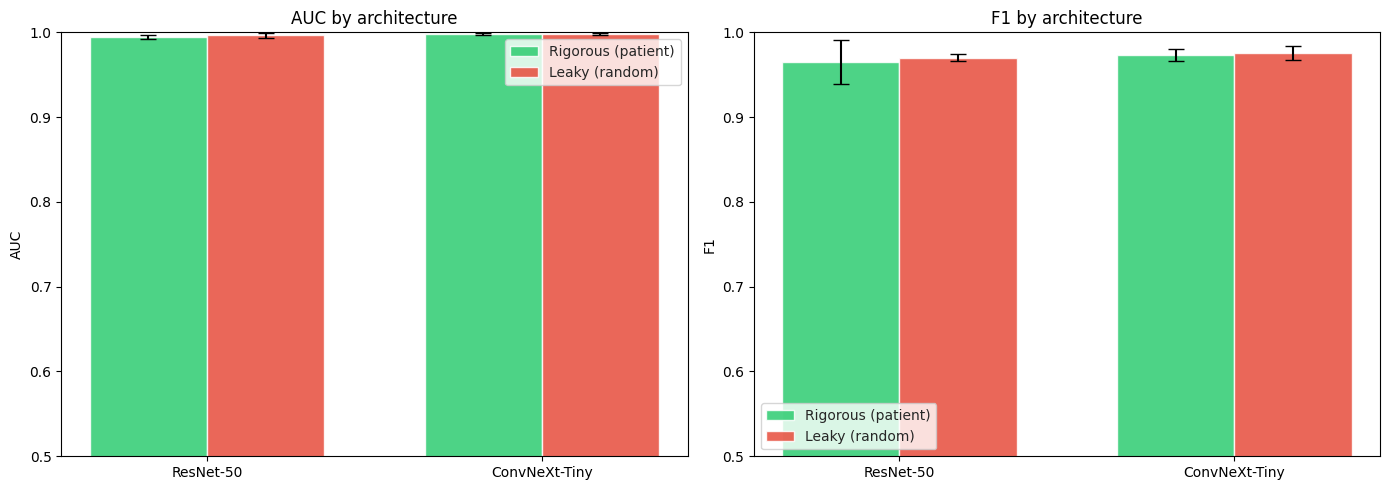

Add-on 2 complete -> addon2_architecture_comparison.{csv,png}


In [12]:
# ====== ADD-ON 2: CONVNEXT-TINY - FULL TWO-ARM PROTOCOL (resumable) ======
CN_PR, CN_RR = [], []
cn_yt, cn_pat, cn_ran = [], [], []
_t0 = time.time()
for f in range(FOLDS):
    if has_ckpt(f'addon2_fold{f+1}'):
        _c = load_pkl_ckpt(f'addon2_fold{f+1}')
        CN_PR.append(_c['rp']); CN_RR.append(_c['rr'])
        cn_yt.extend(_c['rp']['yt']); cn_pat.extend(_c['rp']['yp']); cn_ran.extend(_c['rr']['yp'])
        print(f'  \u23ed  ConvNeXt fold {f+1} loaded from checkpoint (skipped retraining)')
        continue
    ti, ei = gkf[f]
    trG = oct_df.iloc[ti].reset_index(drop=True); teG = oct_df.iloc[ei].reset_index(drop=True)
    if teG.Label.nunique() < 2:
        print(f'Fold {f+1}: single-class test, skipped'); continue
    rp = load_pkl_ckpt(f'addon2_patient_fold{f+1}')
    if rp is None:
        rp = train_arch(trG, teG, f+1, 'ConvNeXt-Patient', mkmodel_convnext, keep_model=False)
        save_pkl_ckpt(rp, f'addon2_patient_fold{f+1}')
    else:
        print(f'  \u23ed  ConvNeXt-Patient fold {f+1} loaded from checkpoint')
    CN_PR.append(rp)
    gc.collect(); torch.cuda.empty_cache()
    ti2, ei2 = rkf[f]
    trR = oct_df.iloc[ti2].reset_index(drop=True); teR = oct_df.iloc[ei2].reset_index(drop=True)
    lm = train_arch(trR, teR, f+1, 'ConvNeXt-Leaky', mkmodel_convnext, keep_model=True, verbose=False)
    _, af, ac, f1f, ytf, ypf, yprf = evl(lm['model'], dl(teG, aug=False, sh=False))
    rr = dict(auc=af, acc=ac, f1=f1f, yt=ytf, yp=ypf, ypr=yprf)
    CN_RR.append(rr)
    del lm['model'], lm; gc.collect(); torch.cuda.empty_cache()
    cn_yt.extend(rp['yt']); cn_pat.extend(rp['yp']); cn_ran.extend(ypf)
    save_pkl_ckpt({'rp': rp, 'rr': rr}, f'addon2_fold{f+1}')
    print(f'  Fold {f+1}: Patient AUC={rp["auc"]:.4f} | Leaky@PatientTest AUC={af:.4f}  (delta={af-rp["auc"]:+.4f})  [checkpoint saved]')
print(f'ConvNeXt two-arm protocol done in {(time.time()-_t0)/60:.1f} min')

def _agg(res_list, met): return ci95([r[met] for r in res_list])
rows = []
for met in ['auc', 'acc', 'f1']:
    for arch, prl, rrl in [('ResNet-50', PR, RR), ('ConvNeXt-Tiny', CN_PR, CN_RR)]:
        pm, pc = _agg(prl, met); rm, rc = _agg(rrl, met)
        rows.append(dict(Architecture=arch, Metric=met.upper(),
                         Rigorous=f'{pm:.4f}+/-{pc:.4f}', Leaky=f'{rm:.4f}+/-{rc:.4f}', Inflation=f'{rm-pm:+.4f}'))
cn_tab = pd.DataFrame(rows)
print('\n=== CROSS-ARCHITECTURE LEAKAGE INFLATION (OCT) ===')
print(cn_tab.to_string(index=False))
cn_tab.to_csv(OUT/'addon2_architecture_comparison.csv', index=False)

from statsmodels.stats.contingency_tables import mcnemar
_yt = np.array(cn_yt); _pp = np.array(cn_pat); _rr = np.array(cn_ran)
_pc = (_pp == _yt); _rc = (_rr == _yt)
_tbl = [[int(np.sum(_pc & _rc)), int(np.sum(_pc & ~_rc))], [int(np.sum(~_pc & _rc)), int(np.sum(~_pc & ~_rc))]]
_mc = mcnemar(_tbl, exact=False, correction=True)
print(f'\nConvNeXt McNemar: chi2={_mc.statistic:.4f}  p={_mc.pvalue:.2e}  ->', 'SIGNIFICANT' if _mc.pvalue<0.05 else 'n.s.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5)); sns.set_style('whitegrid')
archs = ['ResNet-50', 'ConvNeXt-Tiny']; x = np.arange(len(archs)); w = 0.35
for k, met in enumerate(['auc', 'f1']):
    pr_m = [ci95([r[met] for r in PR])[0], ci95([r[met] for r in CN_PR])[0]]
    pr_c = [ci95([r[met] for r in PR])[1], ci95([r[met] for r in CN_PR])[1]]
    rr_m = [ci95([r[met] for r in RR])[0], ci95([r[met] for r in CN_RR])[0]]
    rr_c = [ci95([r[met] for r in RR])[1], ci95([r[met] for r in CN_RR])[1]]
    ax = axes[k]
    ax.bar(x-w/2, pr_m, w, yerr=pr_c, capsize=6, label='Rigorous (patient)', color='#2ecc71', alpha=0.85)
    ax.bar(x+w/2, rr_m, w, yerr=rr_c, capsize=6, label='Leaky (random)', color='#e74c3c', alpha=0.85)
    ax.set(xticks=x, xticklabels=archs, ylabel=met.upper(), title=f'{met.upper()} by architecture', ylim=[0.5, 1.0]); ax.legend()
plt.tight_layout(); plt.savefig(OUT/'addon2_architecture_comparison.png', dpi=300, bbox_inches='tight'); plt.show()
print('Add-on 2 complete -> addon2_architecture_comparison.{csv,png}')

### Add-on 3 - Leakage severity (dose-response)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


   [Leaky-Severity F1] AUC=0.9982 ACC=0.9833 F1=0.9821
  Fold 1: 240 test images scored [checkpoint saved]
   [Leaky-Severity F2] AUC=0.9975 ACC=0.9792 F1=0.9805
  Fold 2: 240 test images scored [checkpoint saved]
   [Leaky-Severity F3] AUC=0.9934 ACC=0.9542 F1=0.9511
  Fold 3: 240 test images scored [checkpoint saved]
   [Leaky-Severity F4] AUC=0.9976 ACC=0.9750 F1=0.9737
  Fold 4: 240 test images scored [checkpoint saved]
   [Leaky-Severity F5] AUC=0.9942 ACC=0.9708 F1=0.9712
  Fold 5: 240 test images scored [checkpoint saved]

=== LEAKAGE SEVERITY: siblinged vs non-siblinged test images ===
               group   n  accuracy  mean_confidence
 No sibling in train 725  0.968276         0.956204
Has sibling in train 475  0.978947         0.969353

Spearman  n_siblings vs correctness : rho=+0.023  p=4.34e-01
Spearman  n_siblings vs confidence  : rho=+0.010  p=7.39e-01


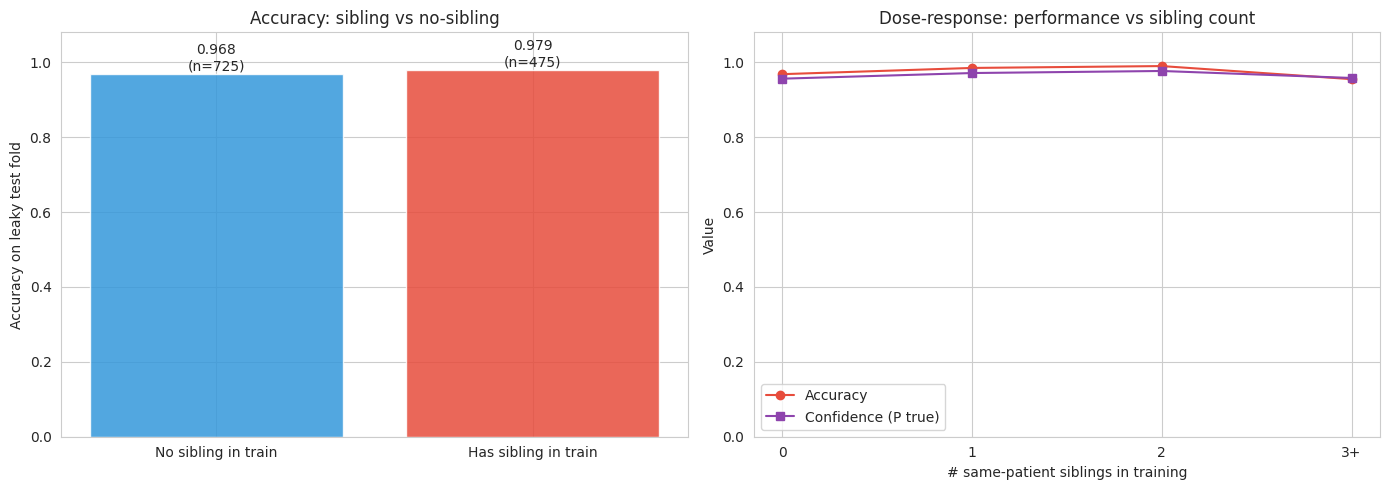

Add-on 3 complete -> addon3_leakage_severity.{csv,png}


In [13]:
# ====== ADD-ON 3: LEAKAGE SEVERITY ANALYSIS (dose-response, resumable) ======
from scipy.stats import spearmanr
sev_records = []
for f in range(FOLDS):
    if has_ckpt(f'addon3_fold{f+1}'):
        sev_records.extend(load_pkl_ckpt(f'addon3_fold{f+1}'))
        print(f'  \u23ed  Severity fold {f+1} loaded from checkpoint (skipped retraining)')
        continue
    ti2, ei2 = rkf[f]
    trR = oct_df.iloc[ti2].reset_index(drop=True)
    teR = oct_df.iloc[ei2].reset_index(drop=True)
    if teR.Label.nunique() < 2:
        continue
    lm = train_arch(trR, teR, f+1, 'Leaky-Severity', mkmodel, keep_model=True, verbose=True)
    _, _, _, _, yt, yp, ypr = evl(lm['model'], dl(teR, aug=False, sh=False))
    tc = trR.Patient_ID.value_counts()
    nsib = teR.Patient_ID.map(tc).fillna(0).astype(int).values
    labels = teR.Label.values.astype(int)
    prob_true = np.where(labels == 1, ypr, 1 - ypr)
    correct = (yp == labels).astype(int)
    fold_records = []
    for k in range(len(teR)):
        fold_records.append(dict(fold=f+1, label=int(labels[k]), n_train_siblings=int(nsib[k]),
                                 has_sibling=int(nsib[k] > 0), correct=int(correct[k]),
                                 prob_true=float(prob_true[k])))
    sev_records.extend(fold_records)
    save_pkl_ckpt(fold_records, f'addon3_fold{f+1}')
    print(f'  Fold {f+1}: {len(fold_records)} test images scored [checkpoint saved]')
    del lm['model'], lm; torch.cuda.empty_cache()

sev_df = pd.DataFrame(sev_records)
sev_df.to_csv(OUT/'addon3_leakage_severity.csv', index=False)

grp = sev_df.groupby('has_sibling').agg(n=('correct', 'size'), accuracy=('correct', 'mean'),
                                        mean_confidence=('prob_true', 'mean')).reset_index()
grp['group'] = grp['has_sibling'].map({0: 'No sibling in train', 1: 'Has sibling in train'})
print('\n=== LEAKAGE SEVERITY: siblinged vs non-siblinged test images ===')
print(grp[['group', 'n', 'accuracy', 'mean_confidence']].to_string(index=False))

rho_c, p_c = spearmanr(sev_df.n_train_siblings, sev_df.correct)
rho_p, p_p = spearmanr(sev_df.n_train_siblings, sev_df.prob_true)
print(f'\nSpearman  n_siblings vs correctness : rho={rho_c:+.3f}  p={p_c:.2e}')
print(f'Spearman  n_siblings vs confidence  : rho={rho_p:+.3f}  p={p_p:.2e}')

def _bucket(n):
    return '0' if n == 0 else ('1' if n == 1 else ('2' if n == 2 else '3+'))
sev_df['sib_bucket'] = sev_df.n_train_siblings.map(_bucket)
order = ['0', '1', '2', '3+']
buck = sev_df.groupby('sib_bucket').agg(accuracy=('correct', 'mean'), confidence=('prob_true', 'mean'),
                                        n=('correct', 'size')).reindex(order).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5)); sns.set_style('whitegrid')
ax = axes[0]
ax.bar(grp['group'], grp['accuracy'], color=['#3498db', '#e74c3c'], alpha=0.85)
for i, v in enumerate(grp['accuracy']):
    ax.text(i, v+0.01, f'{v:.3f}\n(n={int(grp.n.iloc[i])})', ha='center')
ax.set(ylabel='Accuracy on leaky test fold', title='Accuracy: sibling vs no-sibling', ylim=[0, 1.08])
ax = axes[1]
ax.plot(buck.index, buck['accuracy'], marker='o', color='#e74c3c', label='Accuracy')
ax.plot(buck.index, buck['confidence'], marker='s', color='#8e44ad', label='Confidence (P true)')
ax.set(xlabel='# same-patient siblings in training', ylabel='Value',
       title='Dose-response: performance vs sibling count', ylim=[0, 1.08]); ax.legend()
plt.tight_layout(); plt.savefig(OUT/'addon3_leakage_severity.png', dpi=300, bbox_inches='tight'); plt.show()
print('Add-on 3 complete -> addon3_leakage_severity.{csv,png}')

### Add-on 4 - Natural (imbalanced) prevalence

Imbalanced pool: 3333 images | 1858 patients | prevalence=0.100 (333 disease)

Training RIGOROUS (patient-disjoint) arm...
   [NatImb-Patient F1] AUC=0.9973 ACC=0.9910 F1=0.9583
  saved checkpoint: addon4_rigorous
Training LEAKY (random-split) arm...
   [NatImb-Leaky F1] AUC=0.9986 ACC=0.9955 F1=0.9787
  saved checkpoint: addon4_leaky

=== NATURAL-IMBALANCE RESULTS (prevalence=0.100) - same patient-disjoint test fold ===
              Rigorous (patient)  Leaky (random)  Inflation (Leaky-Rigorous)
AUC                       0.9973          0.9986                      0.0013
PR-AUC                    0.9875          0.9919                      0.0044
Macro-F1                  0.9767          0.9881                      0.0115
Balanced-Acc              0.9767          0.9792                      0.0025
Sensitivity               0.9583          0.9583                      0.0000
Specificity               0.9950          1.0000                      0.0050
MCC                       0.9533    

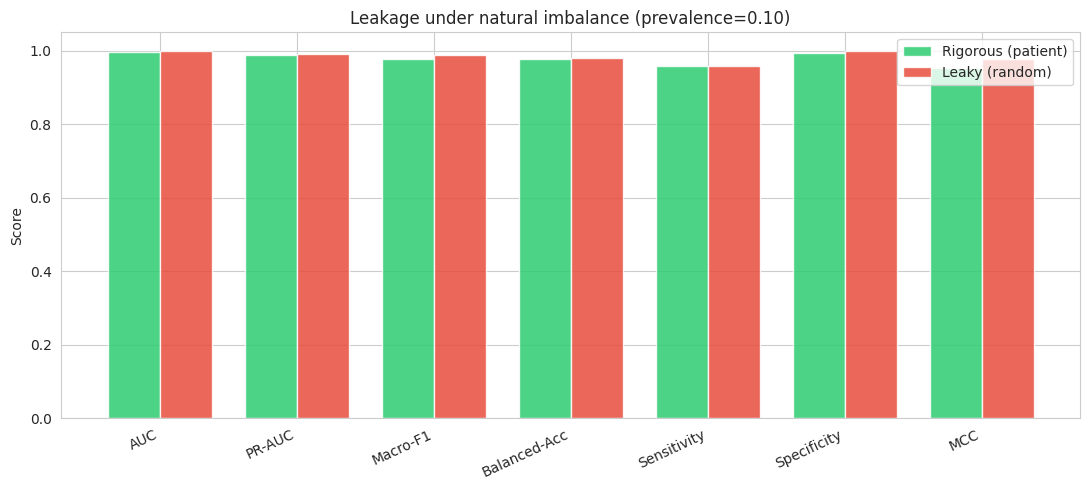

Add-on 4 complete -> addon4_natural_imbalance.{csv,png}


In [14]:
# ====== ADD-ON 4: NATURAL CLASS-IMBALANCE SETTING (resumable) ======
# Drop balanced subsampling: rebuild the FULL pool from disk and down-sample the
# positive (disease) class to a low target prevalence to approximate a screening
# deployment where disease is the rare event. Both arms use identical
# class-weighted training; only the SPLIT differs (patient-disjoint vs random).
# The leaky arm's random 80% may pull same-patient siblings of test subjects into
# training (the leakage under study).
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             balanced_accuracy_score, matthews_corrcoef, recall_score)

NAT_PREV = 0.10        # target positive (disease) prevalence
MAX_NEG  = 3000        # cap normals for notebook tractability

_recs = []
for _f in ALL_IMGS:
    _parts = _f.name.replace('.jpeg', '').split('-')
    if len(_parts) >= 2:
        _dis = _parts[0]
        _recs.append({'filepath': str(_f), 'Patient_ID': _parts[1],
                      'Label': 0 if _dis == 'NORMAL' else 1, 'Disease': _dis})
_full = pd.DataFrame(_recs)
_pos = _full[_full.Label == 1]; _neg = _full[_full.Label == 0]
_nn  = min(len(_neg), MAX_NEG)
_npos = min(len(_pos), max(int(_nn * NAT_PREV / (1 - NAT_PREV)), 1))
nat = pd.concat([_pos.sample(_npos, random_state=SEED),
                 _neg.sample(_nn, random_state=SEED)]).sample(frac=1, random_state=SEED).reset_index(drop=True)
prev = nat.Label.mean()
print(f'Imbalanced pool: {len(nat)} images | {nat.Patient_ID.nunique()} patients | prevalence={prev:.3f} ({int(nat.Label.sum())} disease)')

# Patient-disjoint test fold (shared by BOTH arms)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
_tr, _te = next(gss.split(nat, nat.Label, groups=nat.Patient_ID))
natG_tr = nat.iloc[_tr].reset_index(drop=True); natG_te = nat.iloc[_te].reset_index(drop=True)
# Leaky arm: random 80% of the whole pool
_rng = np.random.RandomState(SEED); _perm = _rng.permutation(len(nat)); _cut = int(0.8*len(nat))
natR_tr = nat.iloc[_perm[:_cut]].reset_index(drop=True)

def _cw(df):
    n = len(df); c = df.Label.value_counts()
    return torch.tensor([n/(2*max(int(c.get(0, 1)), 1)), n/(2*max(int(c.get(1, 1)), 1))],
                        dtype=torch.float32, device=DEVICE)

_rg = load_pkl_ckpt('addon4_rigorous')
if _rg is None:
    print('\nTraining RIGOROUS (patient-disjoint) arm...')
    nat_rig = train_arch(natG_tr, natG_te, 1, 'NatImb-Patient', mkmodel, class_weight=_cw(natG_tr), keep_model=True)
    _, _, _, _, ytg, ypg, yprg = evl(nat_rig['model'], dl(natG_te, aug=False, sh=False))
    save_pkl_ckpt({'yt': ytg, 'yp': ypg, 'ypr': yprg}, 'addon4_rigorous')
    del nat_rig['model'], nat_rig; torch.cuda.empty_cache()
    print('  saved checkpoint: addon4_rigorous')
else:
    ytg, ypg, yprg = _rg['yt'], _rg['yp'], _rg['ypr']; print('Loaded RIGOROUS arm from checkpoint')

_lk = load_pkl_ckpt('addon4_leaky')
if _lk is None:
    print('Training LEAKY (random-split) arm...')
    nat_lk = train_arch(natR_tr, natG_te, 1, 'NatImb-Leaky', mkmodel, class_weight=_cw(natR_tr), keep_model=True)
    _, _, _, _, ytl, ypl, yprl = evl(nat_lk['model'], dl(natG_te, aug=False, sh=False))
    save_pkl_ckpt({'yt': ytl, 'yp': ypl, 'ypr': yprl}, 'addon4_leaky')
    del nat_lk['model'], nat_lk; torch.cuda.empty_cache()
    print('  saved checkpoint: addon4_leaky')
else:
    ytl, ypl, yprl = _lk['yt'], _lk['yp'], _lk['ypr']; print('Loaded LEAKY arm from checkpoint')

def _imb_metrics(yt, yp, ypr):
    return {'AUC': roc_auc_score(yt, ypr), 'PR-AUC': average_precision_score(yt, ypr),
            'Macro-F1': f1_score(yt, yp, average='macro', zero_division=0),
            'Balanced-Acc': balanced_accuracy_score(yt, yp),
            'Sensitivity': recall_score(yt, yp, pos_label=1, zero_division=0),
            'Specificity': recall_score(yt, yp, pos_label=0, zero_division=0),
            'MCC': matthews_corrcoef(yt, yp)}
nat_tab = pd.DataFrame({'Rigorous (patient)': _imb_metrics(ytg, ypg, yprg),
                        'Leaky (random)': _imb_metrics(ytl, ypl, yprl)})
nat_tab['Inflation (Leaky-Rigorous)'] = nat_tab['Leaky (random)'] - nat_tab['Rigorous (patient)']
print(f'\n=== NATURAL-IMBALANCE RESULTS (prevalence={prev:.3f}) - same patient-disjoint test fold ===')
print(nat_tab.round(4).to_string())
nat_tab.to_csv(OUT/'addon4_natural_imbalance.csv')

fig, ax = plt.subplots(figsize=(11, 5)); sns.set_style('whitegrid')
mets = list(nat_tab.index); x = np.arange(len(mets)); w = 0.38
ax.bar(x-w/2, nat_tab['Rigorous (patient)'].values, w, label='Rigorous (patient)', color='#2ecc71', alpha=0.85)
ax.bar(x+w/2, nat_tab['Leaky (random)'].values, w, label='Leaky (random)', color='#e74c3c', alpha=0.85)
ax.set(xticks=x, xticklabels=mets, ylabel='Score', title=f'Leakage under natural imbalance (prevalence={prev:.2f})', ylim=[0, 1.05])
plt.setp(ax.get_xticklabels(), rotation=25, ha='right'); ax.legend()
plt.tight_layout(); plt.savefig(OUT/'addon4_natural_imbalance.png', dpi=300, bbox_inches='tight'); plt.show()
print('Add-on 4 complete -> addon4_natural_imbalance.{csv,png}')

### Bundle everything into one archive

In [15]:
# ====== BUNDLE ALL RESULTS (old base + Add-on 1 + new Add-ons 2-4) ======
import glob, os, zipfile
ARCH = '/kaggle/working/OCT_Final_Q1_Results_WITH_ADDONS.zip'
with zipfile.ZipFile(ARCH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for p in glob.glob(str(OUT) + '/**/*', recursive=True):
        if os.path.isfile(p):
            zf.write(p, os.path.relpath(p, '/kaggle/working'))
print('Final bundle written ->', ARCH)
print('Result files in', OUT, ':')
for p in sorted(glob.glob(str(OUT) + '/*.csv') + glob.glob(str(OUT) + '/*.png')):
    print('   ', os.path.basename(p))

Final bundle written -> /kaggle/working/OCT_Final_Q1_Results_WITH_ADDONS.zip
Result files in /kaggle/working/q1_oct :
    __results___15_0.png
    __results___16_3.png
    __results___18_1.png
    __results___23_7.png
    addon1_border_ratio.csv
    addon1_matched_xai.png
    addon2_architecture_comparison.csv
    addon2_architecture_comparison.png
    addon3_leakage_severity.csv
    addon3_leakage_severity.png
    addon4_natural_imbalance.csv
    addon4_natural_imbalance.png
    comprehensive_analysis.png
    exhaustive_metrics.csv
    fig1_auc_mq.png
    fig2_xai.png
    results.csv
